#### Import lib

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
import numpy as np
import os

dataDirPath="./teaLeafBD/teaLeafBD"

catagories = os.listdir(dataDirPath)
print(catagories)

labels = np.arange(len(catagories))
print(labels)
labelDict = dict(zip(catagories, labels))
print(labelDict)




['1. Tea algal leaf spot', '2. Brown Blight', '3. Gray Blight', '4. Helopeltis', '5. Red spider', '6. Green mirid bug', '7. Healthy leaf']
[0 1 2 3 4 5 6]
{'1. Tea algal leaf spot': np.int64(0), '2. Brown Blight': np.int64(1), '3. Gray Blight': np.int64(2), '4. Helopeltis': np.int64(3), '5. Red spider': np.int64(4), '6. Green mirid bug': np.int64(5), '7. Healthy leaf': np.int64(6)}


In [3]:
import cv2

img_size = 128

data=[]
target=[]

for catagory in catagories:
    catagoryPath = os.path.join(dataDirPath, catagory)
    for img in os.listdir(catagoryPath):
        imgPath = os.path.join(catagoryPath, img)
        try:
            imgArr = cv2.imread(imgPath)
            imgArr = cv2.cvtColor(imgArr, cv2.COLOR_BGR2RGB)
            imgArr = cv2.resize(imgArr, (img_size, img_size))

            imgArr = imgArr.astype("float32") / 255.0
            
            data.append(imgArr)
            target.append(labelDict[catagory])
        except Exception as e:
            print(f"Error processing image {imgPath}: {e}") 



In [4]:
data_new = np.array(data, dtype=np.float32)
target = np.array(target)


In [5]:
print(data_new.shape)
print(target.shape)

(5276, 128, 128, 3)
(5276,)


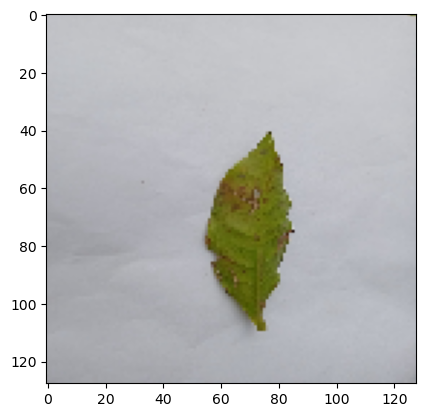

In [6]:
from matplotlib import pyplot as plt

plt.imshow(data_new[500])

In [7]:
print(data_new,data_new.shape)

[[[[0.94509804 0.9411765  0.9254902 ]
   [0.9529412  0.9490196  0.93333334]
   [0.9529412  0.9490196  0.93333334]
   ...
   [0.9843137  0.9843137  0.9843137 ]
   [0.9843137  0.9843137  0.9843137 ]
   [0.9843137  0.9843137  0.9843137 ]]

  [[0.9490196  0.94509804 0.92941177]
   [0.9529412  0.9490196  0.93333334]
   [0.95686275 0.9529412  0.93333334]
   ...
   [0.9843137  0.9843137  0.9843137 ]
   [0.9843137  0.9843137  0.9843137 ]
   [0.9843137  0.9843137  0.9843137 ]]

  [[0.94509804 0.9411765  0.9254902 ]
   [0.96862745 0.9607843  0.94509804]
   [0.9607843  0.95686275 0.9372549 ]
   ...
   [0.9843137  0.9843137  0.9843137 ]
   [0.9843137  0.9843137  0.9843137 ]
   [0.9843137  0.9843137  0.9843137 ]]

  ...

  [[0.9098039  0.9098039  0.9098039 ]
   [0.9137255  0.9137255  0.9098039 ]
   [0.90588236 0.90588236 0.90588236]
   ...
   [0.9843137  0.9843137  0.9843137 ]
   [0.9843137  0.9843137  0.9843137 ]
   [0.9843137  0.9843137  0.9843137 ]]

  [[0.9098039  0.9098039  0.9019608 ]
   [0.9

In [8]:
print(target,target.shape)

[0 0 0 ... 6 6 6] (5276,)


In [9]:
from keras import utils

target_new = utils.to_categorical(target)
print(target_new,target_new.shape)

[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]] (5276, 7)


In [10]:
np.save('data',data_new)
np.save('target',target_new)

In [11]:
import numpy as np

data=np.load('data.npy')
target=np.load('target.npy')



In [12]:
print(data.shape)
print(target.shape)

(5276, 128, 128, 3)
(5276, 7)


In [1]:
import os
print(os.path.getsize("data.npy"))

1037303936
